In [1]:
import pandas as pd

years = {}

for year in range(2019, 2026):
    years[year] = pd.read_csv(
        f"../data/processed/climate_states_{year}.csv"
    )

print("Loaded:", years.keys())

Loaded: dict_keys([2019, 2020, 2021, 2022, 2023, 2024, 2025])


In [2]:
combined = pd.concat(
    years.values(),
    ignore_index=True
)

print(combined.shape)

(34748, 7)


In [3]:
trend = combined.groupby(
    ["latitude", "longitude"]
)["rainfall_mm"].agg(
    ["mean", "std", "min", "max"]
)

print(trend.head())

                        mean       std       min       max
latitude longitude                                        
7.75     74.50      1.984963  0.471441  1.337722  2.571224
         74.75      1.980538  0.460662  1.463586  2.705125
         75.00      1.952026  0.456743  1.476092  2.771328
         75.25      1.898597  0.453921  1.451559  2.766334
8.00     73.50      1.858658  0.579399  0.886894  2.766147


In [4]:
pivot = combined.pivot_table(
    index=["latitude", "longitude"],
    columns="date",
    values="rainfall_mm"
)

pivot["change_2019_2025"] = (
    pivot[2025] - pivot[2019]
)

print(
    pivot["change_2019_2025"]
    .sort_values(ascending=False)
    .head(20)
)

latitude  longitude
34.75     77.00        10.478830
15.00     79.75         6.632412
33.75     76.75         6.052016
14.75     79.75         5.399941
22.00     85.25         4.022984
13.25     76.75         3.951986
22.50     86.25         3.917062
17.50     94.25         3.863420
14.75     78.00         3.770767
14.50     77.75         3.655116
23.25     85.00         3.580846
21.50     83.75         3.556144
21.75     83.75         3.378208
19.50     76.50         3.375103
22.00     85.00         3.311669
33.50     77.00         3.270271
15.00     78.00         3.221885
24.25     73.75         3.195827
13.75     77.25         3.118995
20.00     93.25         3.109339
Name: change_2019_2025, dtype: float64


In [5]:
risk = pd.read_csv(
    "../data/processed/risk_report_2025.csv"
)

print(risk.columns.tolist())
print(risk.head())
print(risk.shape)

['date', 'latitude', 'longitude', 'rainfall_mm', 'max_temperature_c', 'completeness_score', 'anomaly_score', 'year', 'risk', 'risk_score', 'alert']
   date  latitude  longitude  rainfall_mm  max_temperature_c  \
0  2025     34.75      77.00    18.437214          28.818054   
1  2025     33.75      76.75     8.909527          28.555273   
2  2025     33.75      77.00     2.678496          28.555273   
3  2025     19.75      90.50    10.680436          30.602634   
4  2025     19.75      90.75    14.239305          30.602634   

   completeness_score  anomaly_score  year  risk  risk_score  \
0                 1.0       7.281036  2025  HIGH    7.281036   
1                 1.0       5.149227  2025  HIGH    5.149227   
2                 1.0      -5.392466  2025  HIGH    5.392466   
3                 1.0      -5.288937  2025  HIGH    5.288937   
4                 1.0      -9.944141  2025  HIGH    9.944141   

                               alert  
0   HIGH CLIMATE ALERT (34.75, 77.0)  
1  H

In [6]:
import pandas as pd

risk = pd.read_csv(
    "../data/processed/risk_report_2025.csv"
)

print(risk.sort_values(
    "risk_score",
    ascending=False
)[[
    "latitude",
    "longitude",
    "risk_score",
    "alert"
]])

    latitude  longitude  risk_score                                alert
9      19.50      90.75   11.494356  EXTREME CLIMATE ALERT (19.5, 90.75)
10     19.50      91.00   10.365989   EXTREME CLIMATE ALERT (19.5, 91.0)
7      19.75      91.50   10.241394  EXTREME CLIMATE ALERT (19.75, 91.5)
4      19.75      90.75    9.944141    HIGH CLIMATE ALERT (19.75, 90.75)
6      19.75      91.25    8.391130    HIGH CLIMATE ALERT (19.75, 91.25)
11     19.50      91.25    7.962077     HIGH CLIMATE ALERT (19.5, 91.25)
8      19.75      91.75    7.522225    HIGH CLIMATE ALERT (19.75, 91.75)
5      19.75      91.00    7.400709     HIGH CLIMATE ALERT (19.75, 91.0)
0      34.75      77.00    7.281036     HIGH CLIMATE ALERT (34.75, 77.0)
2      33.75      77.00    5.392466     HIGH CLIMATE ALERT (33.75, 77.0)
3      19.75      90.50    5.288937     HIGH CLIMATE ALERT (19.75, 90.5)
12     18.25      90.75    5.203661    HIGH CLIMATE ALERT (18.25, 90.75)
1      33.75      76.75    5.149227    HIGH CLIMATE

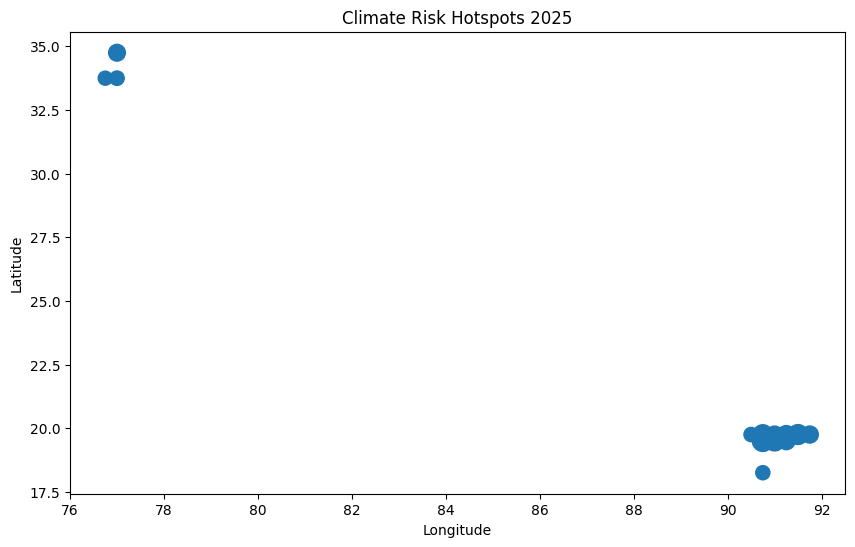

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

risk = pd.read_csv("../data/processed/risk_report_2025.csv")

plt.figure(figsize=(10,6))
plt.scatter(
    risk["longitude"],
    risk["latitude"],
    s=risk["risk_score"]*20
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Climate Risk Hotspots 2025")

plt.show()

In [9]:
risk["alert"].value_counts()


alert
HIGH CLIMATE ALERT (34.75, 77.0)       1
HIGH CLIMATE ALERT (33.75, 76.75)      1
HIGH CLIMATE ALERT (33.75, 77.0)       1
HIGH CLIMATE ALERT (19.75, 90.5)       1
HIGH CLIMATE ALERT (19.75, 90.75)      1
HIGH CLIMATE ALERT (19.75, 91.0)       1
HIGH CLIMATE ALERT (19.75, 91.25)      1
EXTREME CLIMATE ALERT (19.75, 91.5)    1
HIGH CLIMATE ALERT (19.75, 91.75)      1
EXTREME CLIMATE ALERT (19.5, 90.75)    1
EXTREME CLIMATE ALERT (19.5, 91.0)     1
HIGH CLIMATE ALERT (19.5, 91.25)       1
HIGH CLIMATE ALERT (18.25, 90.75)      1
Name: count, dtype: int64

In [10]:
print(risk["risk"].value_counts())

risk
HIGH       10
EXTREME     3
Name: count, dtype: int64


In [11]:
print(risk.groupby("risk")["risk_score"].describe())

         count       mean       std        min        25%        50%  \
risk                                                                   
EXTREME    3.0  10.700580  0.690248  10.241394  10.303691  10.365989   
HIGH      10.0   6.953561  1.639228   5.149227   5.314819   7.340873   

               75%        max  
risk                           
EXTREME  10.930172  11.494356  
HIGH      7.852114   9.944141  


In [14]:
risk = pd.read_csv(
    "../data/processed/risk_report_2025.csv"
)

In [16]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

..\data\processed\climate_2024.csv
..\data\processed\climate_states_2019.csv
..\data\processed\climate_states_2020.csv
..\data\processed\climate_states_2021.csv
..\data\processed\climate_states_2022.csv
..\data\processed\climate_states_2023.csv
..\data\processed\climate_states_2024.csv
..\data\processed\climate_states_2025.csv
..\data\processed\hotspots_2025.csv
..\data\processed\risk_report_2025.csv


In [17]:
import pandas as pd

risk = pd.read_csv("../data/processed/risk_report_2025.csv")

print(risk.head())

   date  latitude  longitude  rainfall_mm  max_temperature_c  \
0  2025     34.75      77.00    18.437214          28.818054   
1  2025     33.75      76.75     8.909527          28.555273   
2  2025     33.75      77.00     2.678496          28.555273   
3  2025     19.75      90.50    10.680436          30.602634   
4  2025     19.75      90.75    14.239305          30.602634   

   completeness_score  anomaly_score  year  risk  risk_score  \
0                 1.0       7.281036  2025  HIGH    7.281036   
1                 1.0       5.149227  2025  HIGH    5.149227   
2                 1.0      -5.392466  2025  HIGH    5.392466   
3                 1.0      -5.288937  2025  HIGH    5.288937   
4                 1.0      -9.944141  2025  HIGH    9.944141   

                               alert  
0   HIGH CLIMATE ALERT (34.75, 77.0)  
1  HIGH CLIMATE ALERT (33.75, 76.75)  
2   HIGH CLIMATE ALERT (33.75, 77.0)  
3   HIGH CLIMATE ALERT (19.75, 90.5)  
4  HIGH CLIMATE ALERT (19.75, 90.75

In [18]:
import pandas as pd

risk = pd.read_csv("../data/processed/risk_report_2025.csv")

top = risk.sort_values(
    "risk_score",
    ascending=False
)

print(top)

    date  latitude  longitude  rainfall_mm  max_temperature_c  \
9   2025     19.50      90.75     9.539024          30.602634   
10  2025     19.50      91.00    11.172183          30.602634   
7   2025     19.75      91.50    16.589584          30.602634   
4   2025     19.75      90.75    14.239305          30.602634   
6   2025     19.75      91.25    21.906561          30.602634   
11  2025     19.50      91.25    14.329947          30.602634   
8   2025     19.75      91.75     8.071321          29.198946   
5   2025     19.75      91.00    20.446770          30.602634   
0   2025     34.75      77.00    18.437214          28.818054   
2   2025     33.75      77.00     2.678496          28.555273   
3   2025     19.75      90.50    10.680436          30.602634   
12  2025     18.25      90.75     4.627009          27.615192   
1   2025     33.75      76.75     8.909527          28.555273   

    completeness_score  anomaly_score  year     risk  risk_score  \
9                  1.

In [19]:
import pandas as pd

all_years = []

for year in range(2019, 2026):
    df = pd.read_csv(
        f"../data/processed/climate_states_{year}.csv"
    )
    all_years.append(df)

combined = pd.concat(all_years)

print(combined.shape)

(34748, 7)


In [20]:
pivot = combined.pivot_table(
    index=["latitude","longitude"],
    columns="date",
    values="rainfall_mm"
)

pivot["change"] = (
    pivot[2025] - pivot[2019]
)

print(
    pivot["change"]
    .sort_values(ascending=False)
    .head(50)
)

latitude  longitude
34.75     77.00        10.478830
15.00     79.75         6.632412
33.75     76.75         6.052016
14.75     79.75         5.399941
22.00     85.25         4.022984
13.25     76.75         3.951986
22.50     86.25         3.917062
17.50     94.25         3.863420
14.75     78.00         3.770767
14.50     77.75         3.655116
23.25     85.00         3.580846
21.50     83.75         3.556144
21.75     83.75         3.378208
19.50     76.50         3.375103
22.00     85.00         3.311669
33.50     77.00         3.270271
15.00     78.00         3.221885
24.25     73.75         3.195827
13.75     77.25         3.118995
20.00     93.25         3.109339
21.25     86.00         3.106575
35.00     76.75         3.086851
35.25     76.75         3.077683
13.00     76.75         3.071575
19.25     75.75         3.043614
16.75     78.25         3.042015
32.25     75.50         3.007068
32.00     74.75         3.003740
18.50     77.25         2.948354
35.00     77.00        

In [21]:
import pandas as pd

rows = []

for year in range(2019, 2026):

    df = pd.read_csv(
        f"../data/processed/climate_states_{year}.csv"
    )

    for _, row in df.iterrows():

        anomaly = row["anomaly_score"]

        if abs(anomaly) >= 10:
            risk = "EXTREME"
        elif abs(anomaly) >= 5:
            risk = "HIGH"
        elif abs(anomaly) >= 2:
            risk = "MODERATE"
        else:
            risk = "LOW"

        rows.append(risk)

benchmark = pd.DataFrame({
    "risk": rows
})

print(benchmark["risk"].value_counts())

risk
LOW         33841
MODERATE      856
HIGH           42
EXTREME         9
Name: count, dtype: int64


In [22]:
import pandas as pd

all_years = []

for year in range(2019, 2026):

    df = pd.read_csv(
        f"../data/processed/climate_states_{year}.csv"
    )

    df["year"] = year

    all_years.append(df)

combined = pd.concat(all_years)

print(combined.head())
print(combined.shape)

   date  latitude  longitude  rainfall_mm  max_temperature_c  \
0  2019     36.75      77.00     3.331672          31.718817   
1  2019     36.75      77.25     3.166381          31.718817   
2  2019     36.75      77.50     2.666646          33.467411   
3  2019     36.75      77.75     2.790045          33.467411   
4  2019     36.50      76.75     5.099447          31.718817   

   completeness_score  anomaly_score  year  
0                 1.0      -0.737311  2019  
1                 1.0      -0.313557  2019  
2                 1.0       0.373344  2019  
3                 1.0       0.405518  2019  
4                 1.0      -0.904384  2019  
(34748, 8)


In [23]:
combined.groupby("year")[
    "anomaly_score"
].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2019,4964.0,0.135367,0.721418,-4.816961,-0.312459,0.040857,0.496165,5.989103
2020,4964.0,0.146384,0.806181,-3.299654,-0.299921,0.050896,0.483516,11.287101
2021,4964.0,0.015166,0.808173,-5.734994,-0.414021,-0.008258,0.440836,5.629350
2022,4964.0,0.103010,0.775868,-3.678762,-0.298442,0.042555,0.434390,12.850145
2023,4964.0,-0.379173,0.796469,-11.312090,-0.740558,-0.289521,0.046459,5.532638
2024,4964.0,-0.020754,0.731974,-10.093552,-0.374844,-0.017242,0.322330,4.487838
2025,4964.0,0.132651,0.978222,-11.494356,-0.272760,0.151930,0.638960,7.281036


In [24]:
import pandas as pd

all_years = []

for year in range(2019, 2026):

    df = pd.read_csv(
        f"../data/processed/climate_states_{year}.csv"
    )

    df["year"] = year

    all_years.append(df)

combined = pd.concat(all_years)

year_stats = combined.groupby("year").agg({
    "rainfall_mm": ["mean", "max"],
    "max_temperature_c": ["mean", "max"],
    "anomaly_score": ["mean", "min", "max"]
})

print(year_stats)

     rainfall_mm            max_temperature_c            anomaly_score  \
            mean        max              mean        max          mean   
year                                                                     
2019    3.476680  26.192291         30.865413  35.065605      0.135367   
2020    3.487696  37.188488         30.680312  34.344482      0.146384   
2021    3.356478  24.584892         30.912408  34.012951      0.015166   
2022    3.444323  36.366596         31.171071  34.380344      0.103010   
2023    2.962140  26.285131         31.062242  34.742630     -0.379173   
2024    3.320558  31.168758         31.150929  34.718754     -0.020754   
2025    3.473964  21.906561         30.802370  33.951836      0.132651   

                            
            min        max  
year                        
2019  -4.816961   5.989103  
2020  -3.299654  11.287101  
2021  -5.734994   5.629350  
2022  -3.678762  12.850145  
2023 -11.312090   5.532638  
2024 -10.093552   4.487838 

In [25]:
combined.groupby("year")["anomaly_score"].agg(
    ["mean","std","min","max"]
)

,mean,std,min,max
year,,,,
2019,0.135367,0.721418,-4.816961,5.989103
2020,0.146384,0.806181,-3.299654,11.287101
2021,0.015166,0.808173,-5.734994,5.629350
2022,0.103010,0.775868,-3.678762,12.850145
2023,-0.379173,0.796469,-11.312090,5.532638
2024,-0.020754,0.731974,-10.093552,4.487838
2025,0.132651,0.978222,-11.494356,7.281036


In [26]:
top_change = pivot["change"].sort_values(
    ascending=False
).head(100)

print(top_change)

latitude  longitude
34.75     77.00        10.478830
15.00     79.75         6.632412
33.75     76.75         6.052016
14.75     79.75         5.399941
22.00     85.25         4.022984
                         ...    
26.75     77.25         2.133976
20.50     87.50         2.127572
19.25     77.50         2.122554
19.00     94.75         2.120558
19.25     95.00         2.118718
Name: change, Length: 100, dtype: float64


In [27]:
top_change.reset_index()

,latitude,longitude,change
0,34.75,77.00,10.478830
1,15.00,79.75,6.632412
2,33.75,76.75,6.052016
3,14.75,79.75,5.399941
4,22.00,85.25,4.022984
...,...,...,...
95,26.75,77.25,2.133976
96,20.50,87.50,2.127572
97,19.25,77.50,2.122554
98,19.00,94.75,2.120558


In [28]:
top100 = top_change.reset_index()

print(
    top100["latitude"].describe()
)

print(
    top100["longitude"].describe()
)

count    100.000000
mean      21.972500
std        6.072988
min       12.500000
25%       18.937500
50%       21.500000
75%       25.250000
max       35.750000
Name: latitude, dtype: float64
count    100.000000
mean      81.745000
std        6.148004
min       73.250000
25%       76.937500
50%       79.125000
75%       85.500000
max       95.000000
Name: longitude, dtype: float64


In [31]:
pivot["change"].describe()

count    4964.000000
mean       -0.002716
std         1.210356
min       -11.011913
25%        -0.595663
50%         0.057888
75%         0.737174
max        10.478830
Name: change, dtype: float64

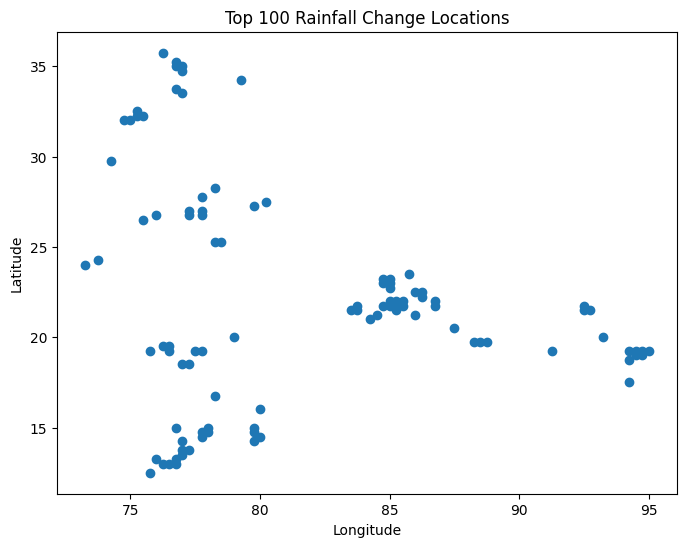

In [29]:
import matplotlib.pyplot as plt

top100 = top_change.reset_index()

plt.figure(figsize=(8,6))

plt.scatter(
    top100["longitude"],
    top100["latitude"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Top 100 Rainfall Change Locations")

plt.show()

In [32]:
pivot["change"].describe()

count    4964.000000
mean       -0.002716
std         1.210356
min       -11.011913
25%        -0.595663
50%         0.057888
75%         0.737174
max        10.478830
Name: change, dtype: float64

In [33]:
print(
    pivot["change"]
    .sort_values()
    .head(20)
)

latitude  longitude
19.50     90.75       -11.011913
19.75     91.75       -10.961906
19.50     91.00        -9.113851
19.75     91.50        -8.304375
          90.75        -7.739857
26.50     73.50        -7.571884
25.75     73.00        -6.190761
18.25     90.75        -5.895623
27.25     73.50        -5.755310
19.50     91.25        -5.592391
26.50     73.25        -5.031262
18.00     90.75        -4.982315
26.25     73.00        -4.945636
19.75     90.50        -4.885855
17.50     93.50        -4.762218
17.00     94.00        -4.553809
18.75     92.50        -4.537712
27.50     73.75        -4.529492
17.00     93.75        -4.498285
34.25     76.25        -4.465589
Name: change, dtype: float64


In [34]:
print("Top increases")
print(
    pivot["change"]
    .sort_values(ascending=False)
    .head(20)
)

print("\nTop decreases")
print(
    pivot["change"]
    .sort_values()
    .head(20)
)

Top increases
latitude  longitude
34.75     77.00        10.478830
15.00     79.75         6.632412
33.75     76.75         6.052016
14.75     79.75         5.399941
22.00     85.25         4.022984
13.25     76.75         3.951986
22.50     86.25         3.917062
17.50     94.25         3.863420
14.75     78.00         3.770767
14.50     77.75         3.655116
23.25     85.00         3.580846
21.50     83.75         3.556144
21.75     83.75         3.378208
19.50     76.50         3.375103
22.00     85.00         3.311669
33.50     77.00         3.270271
15.00     78.00         3.221885
24.25     73.75         3.195827
13.75     77.25         3.118995
20.00     93.25         3.109339
Name: change, dtype: float64

Top decreases
latitude  longitude
19.50     90.75       -11.011913
19.75     91.75       -10.961906
19.50     91.00        -9.113851
19.75     91.50        -8.304375
          90.75        -7.739857
26.50     73.50        -7.571884
25.75     73.00        -6.190761
18.25     9

In [35]:
for year in range(2019, 2026):

    df = pd.read_csv(
        f"../data/processed/climate_states_{year}.csv"
    )

    point = df[
        (df["latitude"] == 19.50)
        &
        (df["longitude"] == 90.75)
    ]

    print(
        year,
        point["rainfall_mm"].values[0],
        point["anomaly_score"].values[0]
    )

2019 20.55093765258789 -0.4824428558349609
2020 28.64754676818848 7.614166259765625
2021 22.457155227661133 1.4237747192382812
2022 33.88352584838867 12.85014533996582
2023 9.721290588378906 -11.312089920043944
2024 10.939828872680664 -10.093551635742188
2025 9.539024353027344 -11.494356155395508


In [36]:
locations = [
    (19.75, 91.75),
    (19.50, 91.00),
    (19.75, 91.50)
]

for lat, lon in locations:

    print("\n", lat, lon)

    for year in range(2019, 2026):

        df = pd.read_csv(
            f"../data/processed/climate_states_{year}.csv"
        )

        point = df[
            (df["latitude"] == lat)
            &
            (df["longitude"] == lon)
        ]

        print(
            year,
            round(point["rainfall_mm"].values[0], 2),
            round(point["anomaly_score"].values[0], 2)
        )


 19.75 91.75
2019 19.03 3.44
2020 26.88 11.29
2021 9.86 -5.73
2022 16.32 0.73
2023 9.63 -5.96
2024 11.84 -3.76
2025 8.07 -7.52

 19.5 91.0
2019 20.29 -1.25
2020 29.23 7.69
2021 21.59 0.05
2022 32.41 10.87
2023 11.95 -9.59
2024 13.76 -7.78
2025 11.17 -10.37

 19.75 91.5
2019 24.89 -1.94
2020 35.46 8.63
2021 21.58 -5.26
2022 33.4 6.57
2023 20.47 -6.36
2024 25.19 -1.64
2025 16.59 -10.24


In [37]:
lat, lon = 34.75, 77.00

for year in range(2019, 2026):

    df = pd.read_csv(
        f"../data/processed/climate_states_{year}.csv"
    )

    point = df[
        (df["latitude"] == lat)
        &
        (df["longitude"] == lon)
    ]

    print(
        year,
        round(point["rainfall_mm"].values[0], 2),
        round(point["anomaly_score"].values[0], 2)
    )

2019 7.96 -3.2
2020 8.91 -2.25
2021 10.36 -0.8
2022 11.08 -0.08
2023 12.99 1.83
2024 15.64 4.49
2025 18.44 7.28


In [38]:
benchmark = []

benchmark.append({
    "question":
    "Which location experienced the largest rainfall increase between 2019 and 2025?",
    "answer":
    "(34.75,77.00)"
})

benchmark.append({
    "question":
    "Which location experienced the largest rainfall decrease between 2019 and 2025?",
    "answer":
    "(19.50,90.75)"
})

benchmark.append({
    "question":
    "Did location (34.75,77.00) become wetter or drier?",
    "answer":
    "Wetter"
})

benchmark.append({
    "question":
    "Did location (19.50,90.75) become wetter or drier?",
    "answer":
    "Drier"
})